In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Load Sample Information

In [2]:
df_sample = pd.read_csv("sample_overview.csv")
#df_sample = df_sample[['Sample', 'Sex', 'Age', 'Age_class', 'Smoking', 'Professional.Asbestos', 'ExtraProfessional.Asbestos', 'Survival.Censor', 'Survival.Time']]
df_sample = df_sample[['Sample', 'Survival.Censor', 'Survival.Time']]

df_sample = df_sample.rename(columns={
    "Survival.Censor": "event",
    "Survival.Time": "duration"
})

df_sample["event"] = df_sample["event"].map({"dead": 1, "alive": 0})

df_sample

,Sample,event,duration
0,MESO_001_T,1,10.1
1,MESO_002_T2,1,30.6
2,MESO_003_T2,1,81.8
3,MESO_006_T,1,9.4
4,MESO_007_T,1,19.8
...,...,...,...
115,MESO_120_T,1,15.9
116,MESO_121_T,1,14.0
117,MESO_122_T,1,4.8
118,MESO_123_T,1,1.2


In [3]:
df_sample.event.value_counts()

event
1    103
0     17
Name: count, dtype: int64

### Load Gene Expression Matrix

In [4]:
df1 = pd.read_csv("gene_FPKM_matrix_1_50.csv")
df2 = pd.read_csv("gene_FPKM_matrix_51_100.csv")
df3 = pd.read_csv("gene_FPKM_matrix_101_129.csv")

In [5]:
df_fpkm = pd.merge(df1, df2, on="gene_id", how="left")
df_fpkm = pd.merge(df_fpkm, df3, on="gene_id", how="left")
df_fpkm

,gene_id,FPKM.MESO_001_T,FPKM.MESO_002_T1,FPKM.MESO_002_T2,FPKM.MESO_003_T1,FPKM.MESO_003_T2,FPKM.MESO_004_T,FPKM.MESO_005_T,FPKM.MESO_006_T,FPKM.MESO_007_T,...,FPKM.MESO_117_T,FPKM.MESO_118_T,FPKM.MESO_119_T,FPKM.MESO_120_T,FPKM.MESO_121_T,FPKM.MESO_122_T,FPKM.MESO_123_T,FPKM.MESO_124_T,FPKM.MESO_054_T,FPKM.MESO_115_T
0,ENSG00000000003.15,1.774147,2.242399,2.943870,5.996907,5.533734,0.684295,5.568203,3.699224,3.971878,...,7.632422,3.663046,4.016722,2.633644,2.416714,4.418121,4.590274,4.236430,4.674138,4.187348
1,ENSG00000000005.6,1.365486,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.174155,0.000000,0.000000,0.000000,0.000000,0.529099,0.057077,0.117698
2,ENSG00000000419.12,9.510056,12.192782,12.002122,9.315892,7.999604,11.299414,14.022787,14.929336,11.860331,...,10.970528,10.734637,9.699542,7.580337,2.416105,10.099431,11.023403,11.146439,6.567659,8.200600
3,ENSG00000000457.14,2.046912,1.852072,2.984588,4.302291,4.229213,2.698941,4.216001,2.217081,3.319499,...,2.908735,2.711429,3.436430,1.705154,1.082705,2.924170,2.456805,2.489392,2.879665,2.590336
4,ENSG00000000460.17,0.352062,0.480680,0.721436,0.482662,0.538495,0.600728,2.730392,0.952406,0.419942,...,0.764354,0.849082,0.904650,0.438431,0.572732,0.660733,0.478224,0.642144,0.580621,0.505648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59602,ENSG00000288588.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
59603,IGH-.g@-ext,5.815518,1.329211,1.016722,0.011038,0.009828,5.963382,0.107280,0.050166,0.309042,...,0.069588,0.011422,0.146623,0.407083,0.807056,1.030245,0.043086,0.218242,0.511166,0.120210
59604,IGH.g@-ext,31.179546,7.063174,4.888905,0.087595,0.083503,48.961254,1.083204,0.424843,1.165450,...,0.523353,0.081630,1.027314,2.494627,2.306974,11.405874,0.278966,2.228218,3.884223,0.467571
59605,IGL-.g@-ext,0.045200,1.080661,0.119542,0.010809,0.007159,4.867609,0.008551,0.036950,0.043254,...,0.013743,0.047640,0.207504,0.308123,0.070024,1.030248,0.002510,0.035393,0.051961,0.044003


In [6]:
df_fpkm.columns = df_fpkm.columns.str.replace("FPKM.", "", regex=False)

In [7]:
#convert FPKM to TPM
df_fpkm_indexed = df_fpkm.set_index('gene_id')
df_tpm = df_fpkm_indexed.div(df_fpkm_indexed.sum(axis=0), axis=1) * 1e6
df_tpm

,MESO_001_T,MESO_002_T1,MESO_002_T2,MESO_003_T1,MESO_003_T2,MESO_004_T,MESO_005_T,MESO_006_T,MESO_007_T,MESO_008_T1,...,MESO_117_T,MESO_118_T,MESO_119_T,MESO_120_T,MESO_121_T,MESO_122_T,MESO_123_T,MESO_124_T,MESO_054_T,MESO_115_T
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,6.043113,7.379979,11.250073,16.520583,14.964608,2.455240,19.474397,11.929571,10.746269,9.902586,...,30.801733,14.260604,15.003084,9.785892,6.651851,15.804235,15.645078,13.708556,19.632208,14.566120
ENSG00000000005.6,4.651130,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.650497,0.000000,0.000000,0.000000,0.000000,1.712097,0.239736,0.409425
ENSG00000000419.12,32.393224,40.127776,45.866408,25.663890,21.632940,40.542139,49.043712,48.145393,32.089179,63.136232,...,44.273136,41.791014,36.229309,28.166431,6.650176,36.127076,37.571178,36.068476,27.585332,28.526628
ENSG00000000457.14,6.972206,6.095371,11.405679,11.852168,11.436854,9.683764,14.745167,7.149832,8.981199,6.994278,...,11.738618,10.555863,12.835604,6.335879,2.980077,10.460163,8.373553,8.055360,12.095104,9.010750
ENSG00000000460.17,1.199196,1.581969,2.756985,1.329663,1.456227,2.155405,9.549354,3.071401,1.136190,3.198941,...,3.084658,3.305561,3.379011,1.629088,1.576408,2.363534,1.629937,2.077896,2.438712,1.758950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288588.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
IGH-.g@-ext,19.808861,4.374579,3.885428,0.030408,0.026577,21.396532,0.375204,0.161780,0.836141,0.259588,...,0.280832,0.044467,0.547660,1.512608,2.221370,3.685330,0.146850,0.706204,2.146988,0.418163
IGH.g@-ext,106.204004,23.245677,18.683072,0.241311,0.225813,175.672299,3.788430,1.370070,3.153229,0.870246,...,2.112066,0.317794,3.837179,9.269342,6.349799,40.800404,0.950803,7.210234,16.314426,1.626494


In [8]:
df_tpm_t = df_tpm.T
df_tpm_t.index.name = "Sample"
df_tpm_t = df_tpm_t.reset_index()
df_tpm_t

gene_id,Sample,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.12,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,...,ENSG00000288582.1,ENSG00000288583.1,ENSG00000288584.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288588.1,IGH-.g@-ext,IGH.g@-ext,IGL-.g@-ext,IGL.g@-ext
0,MESO_001_T,6.043113,4.651130,32.393224,6.972206,1.199196,14.970473,302.327599,66.117212,4.548006,...,0.000000,0.000000,0.054087,0.000000,0.532343,0.0,19.808861,106.204004,0.153961,5.325374
1,MESO_002_T1,7.379979,0.000000,40.127776,6.095371,1.581969,16.513448,137.746470,63.019832,8.237554,...,0.268543,0.000000,0.000000,0.038157,0.353600,0.0,4.374579,23.245677,3.556573,12.640999
2,MESO_002_T2,11.250073,0.000000,45.866408,11.405679,2.756985,25.343239,225.181199,76.948855,11.588650,...,0.451643,0.000000,0.000000,0.017854,1.222724,0.0,3.885428,18.683072,0.456833,12.094867
3,MESO_003_T1,16.520583,0.000000,25.663890,11.852168,1.329663,8.545521,451.583429,45.895483,8.817904,...,0.122439,0.000000,0.000000,0.000000,1.276355,0.0,0.030408,0.241311,0.029777,0.208300
4,MESO_003_T2,14.964608,0.000000,21.632940,11.436854,1.456227,11.565724,408.892360,42.702931,10.512791,...,0.000000,0.000000,0.000000,0.000000,0.815137,0.0,0.026577,0.225813,0.019360,0.219583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,MESO_122_T,15.804235,0.000000,36.127076,10.460163,2.363534,16.676834,371.159080,106.958423,7.416452,...,0.248408,1.167890,0.000000,0.000000,1.318677,0.0,3.685330,40.800404,3.685341,14.234640
124,MESO_123_T,15.645078,0.000000,37.571178,8.373553,1.629937,5.412703,124.259493,77.630548,5.888664,...,0.679651,0.000000,0.000000,0.056394,0.816600,0.0,0.146850,0.950803,0.008555,0.781522
125,MESO_124_T,13.708556,1.712097,36.068476,8.055360,2.077896,15.266580,248.666669,75.815933,6.264675,...,0.000000,0.000000,0.000000,0.048169,0.463953,0.0,0.706204,7.210234,0.114527,4.079376
126,MESO_054_T,19.632208,0.239736,27.585332,12.095104,2.438712,16.897011,108.185114,57.975851,7.482524,...,0.169172,0.286435,0.000000,0.036605,1.229988,0.0,2.146988,16.314426,0.218245,4.851180


In [9]:
df_tpm_t.columns

Index(['Sample', 'ENSG00000000003.15', 'ENSG00000000005.6',
       'ENSG00000000419.12', 'ENSG00000000457.14', 'ENSG00000000460.17',
       'ENSG00000000938.13', 'ENSG00000000971.16', 'ENSG00000001036.14',
       'ENSG00000001084.13',
       ...
       'ENSG00000288582.1', 'ENSG00000288583.1', 'ENSG00000288584.1',
       'ENSG00000288585.1', 'ENSG00000288586.1', 'ENSG00000288588.1',
       'IGH-.g@-ext', 'IGH.g@-ext', 'IGL-.g@-ext', 'IGL.g@-ext'],
      dtype='object', name='gene_id', length=59608)

### Overlapping:
the samples has corresponding FPKM values

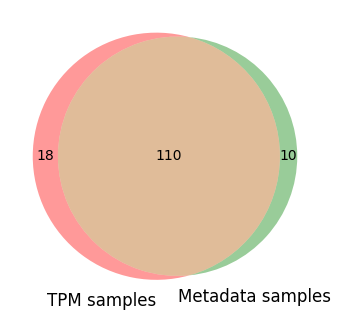

In [10]:
tpm_samples = set(df_tpm_t.Sample)
meta_samples = set(df_sample.Sample)

plt.figure(figsize=(4,4))
venn2(
    [tpm_samples, meta_samples],
    set_labels=("TPM samples", "Metadata samples")
)
plt.show()

The two tables don't have identical sample names. In addition, the paper says 120 MPM tumours and 126 RNA-Seq datasets. What a headache!

In [11]:
overlap = tpm_samples & meta_samples
only_tpm = tpm_samples - meta_samples
only_meta = meta_samples - tpm_samples

print("Overlapping samples:", sorted(overlap))

Overlapping samples: ['MESO_001_T', 'MESO_002_T2', 'MESO_003_T2', 'MESO_006_T', 'MESO_007_T', 'MESO_009_T', 'MESO_010_T', 'MESO_011_T', 'MESO_012_T', 'MESO_013_T', 'MESO_014_T', 'MESO_015_T', 'MESO_016_T', 'MESO_017_T', 'MESO_018_T', 'MESO_019_T', 'MESO_020_T', 'MESO_021_T', 'MESO_022_T', 'MESO_023_T', 'MESO_024_T', 'MESO_025_T', 'MESO_026_T', 'MESO_027_T', 'MESO_028_T', 'MESO_029_T', 'MESO_030_T', 'MESO_031_T', 'MESO_032_T', 'MESO_033_T', 'MESO_034_T', 'MESO_035_T', 'MESO_036_T', 'MESO_037_T', 'MESO_038_T', 'MESO_039_T', 'MESO_040_T', 'MESO_041_T1', 'MESO_042_T1', 'MESO_043_T', 'MESO_044_T', 'MESO_045_T', 'MESO_046_T', 'MESO_047_T', 'MESO_048_T1', 'MESO_049_T', 'MESO_050_T', 'MESO_051_T', 'MESO_052_T2', 'MESO_053_T', 'MESO_054_T', 'MESO_055_T', 'MESO_056_T2', 'MESO_057_T2', 'MESO_058_T2', 'MESO_059_T1', 'MESO_060_T', 'MESO_061_T', 'MESO_062_T2', 'MESO_063_T', 'MESO_064_T', 'MESO_065_T', 'MESO_074_T', 'MESO_075_T', 'MESO_076_T', 'MESO_077_T', 'MESO_078_T', 'MESO_079_T', 'MESO_080_T', '

In [12]:
print("Only in TPM samples:", sorted(only_tpm))

Only in TPM samples: ['MESO_002_T1', 'MESO_003_T1', 'MESO_004_T', 'MESO_005_T', 'MESO_008_T1', 'MESO_008_T2', 'MESO_041_T2', 'MESO_042_T2', 'MESO_048_T2', 'MESO_051_TR', 'MESO_052_T1', 'MESO_056_T1', 'MESO_057_T1', 'MESO_058_T1', 'MESO_059_T2', 'MESO_062_T1', 'MESO_094_T2', 'MESO_115_TR']


In [13]:
print("Only in Metadata samples:", sorted(only_meta))

Only in Metadata samples: ['MESO_066_T', 'MESO_067_T', 'MESO_068_T', 'MESO_069_T', 'MESO_070_T', 'MESO_071_T', 'MESO_072_T', 'MESO_073_T', 'MESO_114_T', 'MESO_116_T']


### Merge Sample Info and Gene Expression, Cleaning

In [14]:
df_merged = pd.merge(df_sample, df_tpm_t, on="Sample", how="left")
df_merged

,Sample,event,duration,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.12,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,...,ENSG00000288582.1,ENSG00000288583.1,ENSG00000288584.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288588.1,IGH-.g@-ext,IGH.g@-ext,IGL-.g@-ext,IGL.g@-ext
0,MESO_001_T,1,10.1,6.043113,4.651130,32.393224,6.972206,1.199196,14.970473,302.327599,...,0.000000,0.000000,0.054087,0.000000,0.532343,0.0,19.808861,106.204004,0.153961,5.325374
1,MESO_002_T2,1,30.6,11.250073,0.000000,45.866408,11.405679,2.756985,25.343239,225.181199,...,0.451643,0.000000,0.000000,0.017854,1.222724,0.0,3.885428,18.683072,0.456833,12.094867
2,MESO_003_T2,1,81.8,14.964608,0.000000,21.632940,11.436854,1.456227,11.565724,408.892360,...,0.000000,0.000000,0.000000,0.000000,0.815137,0.0,0.026577,0.225813,0.019360,0.219583
3,MESO_006_T,1,9.4,11.929571,0.000000,48.145393,7.149832,3.071401,7.789782,15.012338,...,0.218386,0.000000,0.000000,0.000000,1.007628,0.0,0.161780,1.370070,0.119160,0.802700
4,MESO_007_T,1,19.8,10.746269,0.000000,32.089179,8.981199,1.136190,2.629519,57.303259,...,0.000000,0.000000,0.000000,0.000000,0.942882,0.0,0.836141,3.153229,0.117028,2.078509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,MESO_120_T,1,15.9,9.785892,0.000000,28.166431,6.335879,1.629088,11.021348,266.181659,...,0.000000,0.351392,0.000000,0.000000,0.364044,0.0,1.512608,9.269342,1.144900,5.433434
116,MESO_121_T,1,14.0,6.651851,0.000000,6.650176,2.980077,1.576408,2.946136,25.347636,...,0.000000,0.000000,0.000000,0.000000,0.822012,0.0,2.221370,6.349799,0.192737,1.849202
117,MESO_122_T,1,4.8,15.804235,0.000000,36.127076,10.460163,2.363534,16.676834,371.159080,...,0.248408,1.167890,0.000000,0.000000,1.318677,0.0,3.685330,40.800404,3.685341,14.234640
118,MESO_123_T,1,1.2,15.645078,0.000000,37.571178,8.373553,1.629937,5.412703,124.259493,...,0.679651,0.000000,0.000000,0.056394,0.816600,0.0,0.146850,0.950803,0.008555,0.781522


In [15]:
#remove the sample rows with NaN in all gene cols
gene_cols = df_merged.columns[3:]
df_merged = df_merged[~df_merged[gene_cols].isna().all(axis=1)]
df_merged = df_merged.reset_index(drop=True)
df_merged

,Sample,event,duration,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.12,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,...,ENSG00000288582.1,ENSG00000288583.1,ENSG00000288584.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288588.1,IGH-.g@-ext,IGH.g@-ext,IGL-.g@-ext,IGL.g@-ext
0,MESO_001_T,1,10.1,6.043113,4.651130,32.393224,6.972206,1.199196,14.970473,302.327599,...,0.000000,0.000000,0.054087,0.000000,0.532343,0.0,19.808861,106.204004,0.153961,5.325374
1,MESO_002_T2,1,30.6,11.250073,0.000000,45.866408,11.405679,2.756985,25.343239,225.181199,...,0.451643,0.000000,0.000000,0.017854,1.222724,0.0,3.885428,18.683072,0.456833,12.094867
2,MESO_003_T2,1,81.8,14.964608,0.000000,21.632940,11.436854,1.456227,11.565724,408.892360,...,0.000000,0.000000,0.000000,0.000000,0.815137,0.0,0.026577,0.225813,0.019360,0.219583
3,MESO_006_T,1,9.4,11.929571,0.000000,48.145393,7.149832,3.071401,7.789782,15.012338,...,0.218386,0.000000,0.000000,0.000000,1.007628,0.0,0.161780,1.370070,0.119160,0.802700
4,MESO_007_T,1,19.8,10.746269,0.000000,32.089179,8.981199,1.136190,2.629519,57.303259,...,0.000000,0.000000,0.000000,0.000000,0.942882,0.0,0.836141,3.153229,0.117028,2.078509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,MESO_120_T,1,15.9,9.785892,0.000000,28.166431,6.335879,1.629088,11.021348,266.181659,...,0.000000,0.351392,0.000000,0.000000,0.364044,0.0,1.512608,9.269342,1.144900,5.433434
106,MESO_121_T,1,14.0,6.651851,0.000000,6.650176,2.980077,1.576408,2.946136,25.347636,...,0.000000,0.000000,0.000000,0.000000,0.822012,0.0,2.221370,6.349799,0.192737,1.849202
107,MESO_122_T,1,4.8,15.804235,0.000000,36.127076,10.460163,2.363534,16.676834,371.159080,...,0.248408,1.167890,0.000000,0.000000,1.318677,0.0,3.685330,40.800404,3.685341,14.234640
108,MESO_123_T,1,1.2,15.645078,0.000000,37.571178,8.373553,1.629937,5.412703,124.259493,...,0.679651,0.000000,0.000000,0.056394,0.816600,0.0,0.146850,0.950803,0.008555,0.781522


In [16]:
#remove the gene cols with 0 in all gene rows
zero_counts = (df_merged[gene_cols] == 0).sum()
zero_counts = zero_counts.sort_values()
zero_counts

ENSG00000235718.9             0
ENSG00000174348.14            0
ENSG00000174353.17            0
ENSG00000174365.20            0
ENSG00000174370.10            0
                           ... 
ENSG00000068985.5           110
ENSG00000054796.13          110
ENSG00000288567.1           110
ENSG00000288566.1           110
ENSG00000002586.20_PAR_Y    110
Length: 59607, dtype: int64

In [17]:
(zero_counts >=107).sum()
#test = ((zero_counts <= 10) & (zero_counts > 5)).sum()

np.int64(12453)

In [18]:
59607-12453

47154

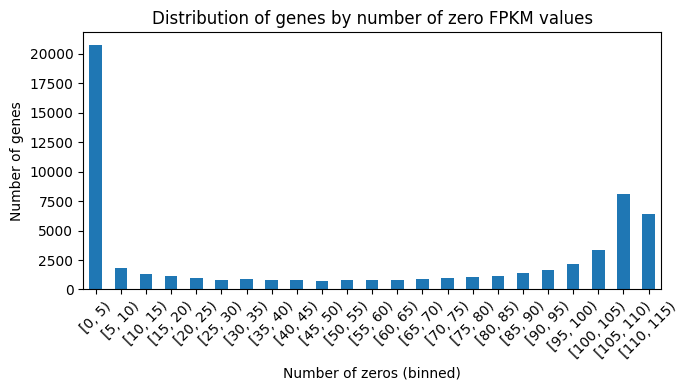

In [19]:
max_zeros = zero_counts.max()
bins = np.arange(0, max_zeros+6, 5)
binned = pd.cut(zero_counts, bins=bins, right=False)
bin_counts = binned.value_counts().sort_index()

plt.figure(figsize=(7,4))
bin_counts.plot(kind='bar')
plt.xlabel("Number of zeros (binned)")
plt.ylabel("Number of genes")
plt.title("Distribution of genes by number of zero FPKM values")
plt.xticks(rotation=45)
plt.tight_layout()

In [20]:
# Remove gene columns with zero counts >= 107
df_merged = df_merged.drop(columns=zero_counts[zero_counts >= 107].index)
df_merged

,Sample,event,duration,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.12,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,...,ENSG00000288580.1,ENSG00000288581.1,ENSG00000288582.1,ENSG00000288583.1,ENSG00000288585.1,ENSG00000288586.1,IGH-.g@-ext,IGH.g@-ext,IGL-.g@-ext,IGL.g@-ext
0,MESO_001_T,1,10.1,6.043113,4.651130,32.393224,6.972206,1.199196,14.970473,302.327599,...,0.028217,0.0,0.000000,0.000000,0.000000,0.532343,19.808861,106.204004,0.153961,5.325374
1,MESO_002_T2,1,30.6,11.250073,0.000000,45.866408,11.405679,2.756985,25.343239,225.181199,...,0.000000,0.0,0.451643,0.000000,0.017854,1.222724,3.885428,18.683072,0.456833,12.094867
2,MESO_003_T2,1,81.8,14.964608,0.000000,21.632940,11.436854,1.456227,11.565724,408.892360,...,0.070543,0.0,0.000000,0.000000,0.000000,0.815137,0.026577,0.225813,0.019360,0.219583
3,MESO_006_T,1,9.4,11.929571,0.000000,48.145393,7.149832,3.071401,7.789782,15.012338,...,0.000000,0.0,0.218386,0.000000,0.000000,1.007628,0.161780,1.370070,0.119160,0.802700
4,MESO_007_T,1,19.8,10.746269,0.000000,32.089179,8.981199,1.136190,2.629519,57.303259,...,0.000000,0.0,0.000000,0.000000,0.000000,0.942882,0.836141,3.153229,0.117028,2.078509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,MESO_120_T,1,15.9,9.785892,0.000000,28.166431,6.335879,1.629088,11.021348,266.181659,...,0.000000,0.0,0.000000,0.351392,0.000000,0.364044,1.512608,9.269342,1.144900,5.433434
106,MESO_121_T,1,14.0,6.651851,0.000000,6.650176,2.980077,1.576408,2.946136,25.347636,...,0.000000,0.0,0.000000,0.000000,0.000000,0.822012,2.221370,6.349799,0.192737,1.849202
107,MESO_122_T,1,4.8,15.804235,0.000000,36.127076,10.460163,2.363534,16.676834,371.159080,...,0.073417,0.0,0.248408,1.167890,0.000000,1.318677,3.685330,40.800404,3.685341,14.234640
108,MESO_123_T,1,1.2,15.645078,0.000000,37.571178,8.373553,1.629937,5.412703,124.259493,...,0.000000,0.0,0.679651,0.000000,0.056394,0.816600,0.146850,0.950803,0.008555,0.781522


In [21]:
# df_merged.columns = df_merged.columns.str.replace(r'\.\d+$', '', regex=True)
# df_merged.to_csv("mesomics_tpm.csv", index=False)

In [22]:
# df_shuffled = df_merged.sample(frac=1, random_state=42).reset_index(drop=True)

# half = len(df_shuffled) // 2
# df_part1 = df_shuffled.iloc[:half]
# df_part2 = df_shuffled.iloc[half:]

# df_part1.to_csv("df_part1_random.csv", index=False)
# df_part2.to_csv("df_part2_random.csv", index=False)

### PCA

In [23]:
expr = df_merged.iloc[:, 3:]
samples = df_merged['Sample']
    
#reduce skewness
expr_log = np.log2(expr + 1)

#ensures each gene contributes equally to PCA
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_log)

pca = PCA(n_components=min(expr_scaled.shape))
pca_result = pca.fit_transform(expr)

pca_df = pd.DataFrame({
    'Sample': samples,
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'event': df_merged['event'],
    'duration': df_merged['duration']
})

pca_df

,Sample,PC1,PC2,event,duration
0,MESO_001_T,2156.733948,-9951.727477,1,10.1
1,MESO_002_T2,-10735.735539,-10706.373813,1,30.6
2,MESO_003_T2,4610.065635,47717.853379,1,81.8
3,MESO_006_T,-32534.886746,-10907.831780,1,9.4
4,MESO_007_T,-13767.390340,61061.621539,1,19.8
...,...,...,...,...,...
105,MESO_120_T,28044.119172,-9524.873088,1,15.9
106,MESO_121_T,-40074.418030,-20197.303308,1,14.0
107,MESO_122_T,28006.171150,-7658.671595,1,4.8
108,MESO_123_T,10111.359528,-9768.649508,1,1.2


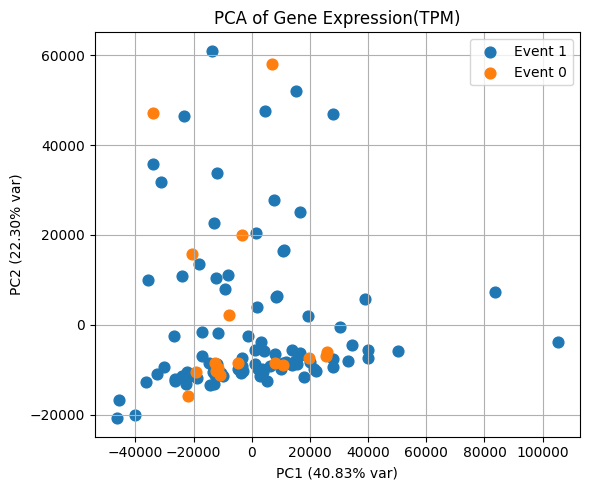

In [24]:
plt.figure(figsize=(6, 5))
for event in pca_df['event'].unique():
    subset = pca_df[pca_df['event'] == event]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Event {event}', s=60)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of Gene Expression(TPM)")
plt.legend()
plt.grid(True)
plt.tight_layout()

Number of PCs to capture 95% variance: 20


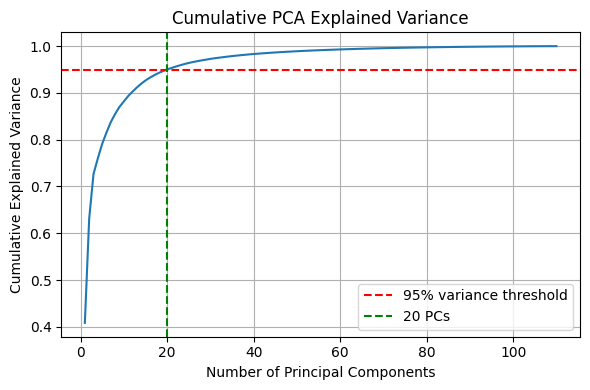

In [25]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

n_components = np.argmax(cumulative_var >= 0.95) + 1
print(f"Number of PCs to capture 95% variance: {n_components}")

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(cumulative_var) + 1), cumulative_var)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} PCs')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()

In [26]:
#pd.set_option('display.float_format', '{:.2f}'.format)
pca_var_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_var))],
    'Explained_Variance': explained_var * 100,
})

pca_var_df.head(20)

,PC,Explained_Variance
0,PC1,40.830033
1,PC2,22.300020
2,PC3,9.533215
3,PC4,3.346054
4,PC5,3.085631
5,PC6,2.444007
6,PC7,2.237179
7,PC8,1.734733
8,PC9,1.504007
9,PC10,1.158643
